In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score, roc_curve)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [2]:
df = pd.read_csv(r"C:\Users\seven\Downloads\Loan_Default.csv\Loan_Default.csv")

In [3]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [5]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [6]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (148670, 34)


Status
0    112031
1     36639
Name: count, dtype: int64


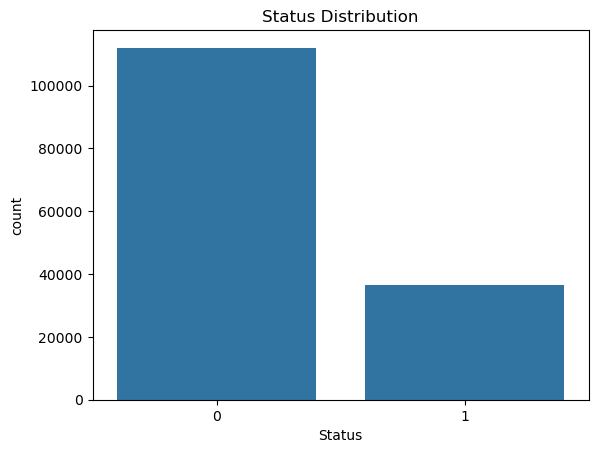

In [7]:
# Check target distribution
print(df['Status'].value_counts())
sns.countplot(x='Status', data=df)
plt.title('Status Distribution')
plt.show()

In [8]:
df.isnull().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [9]:
# Proportion of defaults
default_rate = df['Status'].mean()
print(f"Default rate: {default_rate:.2%}")

Default rate: 24.64%


In [10]:
df = df.drop(columns=['ID'])

In [11]:
X = df.drop(columns=['Status'])
y = df['Status']

In [12]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns: {cat_cols}")
print(f"Numerical columns: {num_cols}")

Categorical columns: ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'Security_Type']
Numerical columns: ['year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'dtir1']


### Handle Missing Values
### For numerical: fill with median.
### For categorical: fill with the most frequent value (mode).

In [13]:
num_imputer = SimpleImputer(strategy='median')

cat_imputer = SimpleImputer(strategy='most_frequent')


### Encode Categorical Variables
### We use `OneHotEncoder` for nominal categorical variables (no ordinal relationship).
### For high-cardinality columns, we could use label encoding, but here we'll use one-hot with drop='first' to avoid multicollinearity.

In [14]:
from sklearn.preprocessing import OneHotEncoder

# Preprocessor for numerical and categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_imputer, num_cols),
        ('cat', cat_imputer, cat_cols)
    ],
    remainder='passthrough'  # Keep other columns as is (not used)
)


In [15]:
# After imputation, we need to one-hot encode categoricals.
# We can chain imputation and encoding using a Pipeline.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [16]:

# Define separate transformers for numerical and categorical
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

In [17]:
# Combine into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (118936, 32)
Test shape: (29734, 32)


In [19]:
# Random Forest model
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# Full pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf)
])

In [20]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['year', 'loan_amount',
                                                   'rate_of_interest',
                                                   'Interest_rate_spread',
                                                   'Upfront_charges', 'term',
                                                   'property_value', 'income',
                                                   'Credit_Score', 'LTV',
                                                   'dtir1']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequen...
                                                   'Credit_Worthiness',
                                                   'open_credit',
                                                   'business_or_commercial',
                                                   'Neg_ammortization',
                                                   'interest_only',
                                                   'lump_sum_payment',
                                                   'construction_type',
                                                   'occupancy_type',
                                                   'Secured_by', 'total_units',
                                                   'credit_type',
                                                   'co-applicant_credit_type',
                                                   'age',
                                                   'submission_of_application',
                                                   'Region',
                                                   'Security_Type'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=10, n_jobs=-1,
                                        random_state=42))])

In [21]:
# Predict on test set
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]  # probability of class 1

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000
ROC-AUC: 1.0000


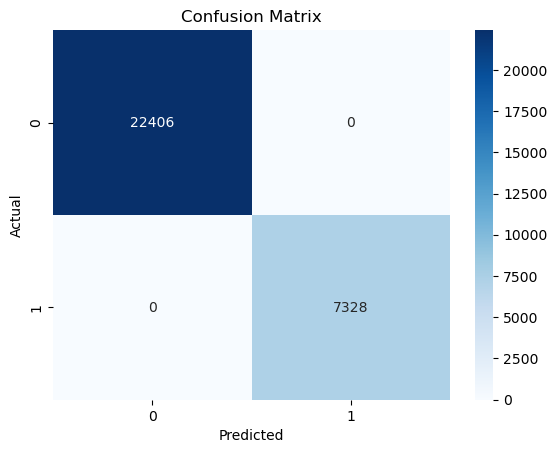

In [22]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

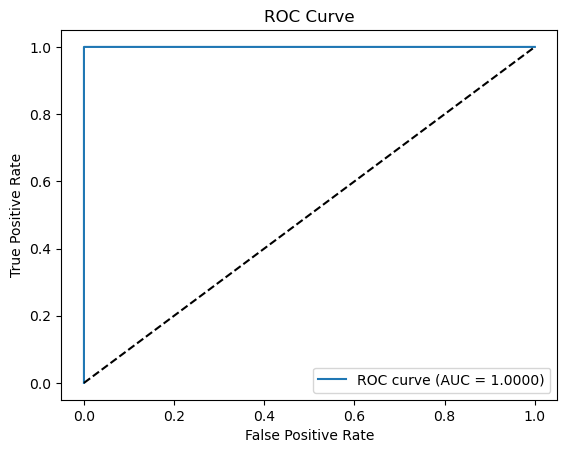

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [24]:
preprocessor.fit(X_train)
# Get feature names for numerical and categorical
num_features = num_cols
cat_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)
all_features = np.concatenate([num_features, cat_features])

In [25]:
# Get feature importances
importances = pipeline.named_steps['classifier'].feature_importances_

In [26]:
# Create a DataFrame for visualization
feature_imp_df = pd.DataFrame({'feature': all_features, 'importance': importances})
feature_imp_df = feature_imp_df.sort_values('importance', ascending=False)

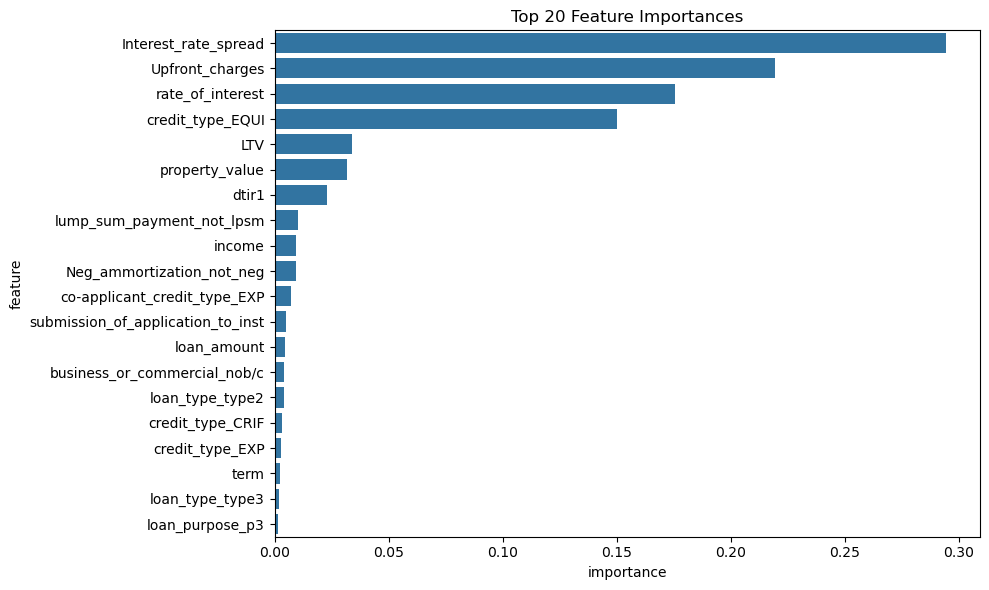

In [27]:
# Plot top 20 features
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_imp_df.head(20))
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

### Model evaluation on sample set

In [28]:
# Select a sample from the test set (e.g., first row)
sample_index = 0
sample = X_test.iloc[[sample_index]]  # keep as DataFrame

# Predict probability of default
prob_default = pipeline.predict_proba(sample)[0, 1]
pred_class = pipeline.predict(sample)[0]

print(f"Sample input (first row of test set):")
print(sample.iloc[0].to_dict())
print(f"\nPredicted class: {pred_class} (0 = No Default, 1 = Default)")
print(f"Probability of default: {prob_default:.4f}")


Sample input (first row of test set):
{'year': 2019, 'loan_limit': 'cf', 'Gender': 'Joint', 'approv_in_adv': 'nopre', 'loan_type': 'type1', 'loan_purpose': 'p3', 'Credit_Worthiness': 'l1', 'open_credit': 'nopc', 'business_or_commercial': 'nob/c', 'loan_amount': 626500, 'rate_of_interest': 3.75, 'Interest_rate_spread': -0.01, 'Upfront_charges': 661.5, 'term': 360.0, 'Neg_ammortization': 'not_neg', 'interest_only': 'not_int', 'lump_sum_payment': 'not_lpsm', 'property_value': 1308000.0, 'construction_type': 'sb', 'occupancy_type': 'pr', 'Secured_by': 'home', 'total_units': '1U', 'income': 13080.0, 'credit_type': 'CIB', 'Credit_Score': 596, 'co-applicant_credit_type': 'EXP', 'age': '35-44', 'submission_of_application': 'not_inst', 'LTV': 47.89755352, 'Region': 'south', 'Security_Type': 'direct', 'dtir1': 25.0}

Predicted class: 0 (0 = No Default, 1 = Default)
Probability of default: 0.0078


In [29]:
sample

,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,...,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,dtir1
59366,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,626500,...,13080.0,CIB,596,EXP,35-44,not_inst,47.897554,south,direct,25.0
